Number of input files: 196500
Number of output files: 196500


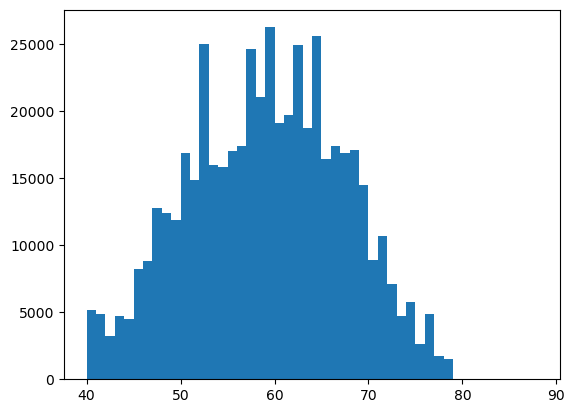

In [1]:
import numpy as np
import os,glob
import matplotlib.pyplot as plt
input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'

training_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training'


input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '*.npy')))
output_filepaths = sorted(glob.glob(os.path.join(output_data_dir, '*.npy')))

print(f'Number of input files: {len(input_filepaths)}')
print(f'Number of output files: {len(output_filepaths)}')

def midi_hist(output_filepaths):
    hist =[]# np.zeros((89,), dtype=int)
    for output_filepath in output_filepaths:
        output_data = np.load(output_filepath)
        for frame in output_data:
            for note in range(89):
                if frame[note] == 1:
                    hist.append(note)
    plt.hist(hist,range(40,89))
  

midi_hist(output_filepaths)





In [2]:
# The limit of samples with midi notes off to be put into the trainingset
sailent_thresh=2000 
current_sailent_count=np.zeros(89,dtype=int)
selected_outfiles=[]
selected_infiles=[]
 
rng=np.random.default_rng(123)
perm=rng.permutation(len(output_filepaths))
output_filepaths=[output_filepaths[i] for i in perm]
input_filepaths=[input_filepaths[i] for i in perm]
for i,output_filepath in enumerate(output_filepaths):
    output_data=np.load(output_filepath)


    # print(output_data.shape)
    # print("out path:", output_filepath)
    # print("in path:", input_filepaths[i])
    if output_data[0][88]>0:
        if current_sailent_count[88]<sailent_thresh:
            selected_outfiles.append(output_filepath)
            selected_infiles.append(input_filepaths[i])
            current_sailent_count[88]+=1
    else:
        selected_outfiles.append(output_filepath)
        selected_infiles.append(input_filepaths[i])


# for i,output_filepath in enumerate(output_filepaths):
#     output_data=np.load(output_filepath)
#     copydata=True
#     for note in range(89):
#         if output_data[0][note]>0:
#             if current_sailent_count[note]>sailent_thresh:
#                 copydata=False

#     # print(output_data.shape)
#     # print("out path:", output_filepath)
#     # print("in path:", input_filepaths[i])

#     if copydata:
#         selected_outfiles.append(output_filepath)
#         selected_infiles.append(input_filepaths[i])
#         for note in range(89):
#             if output_data[0][note]>0:
#                 current_sailent_count[note]+=1
   


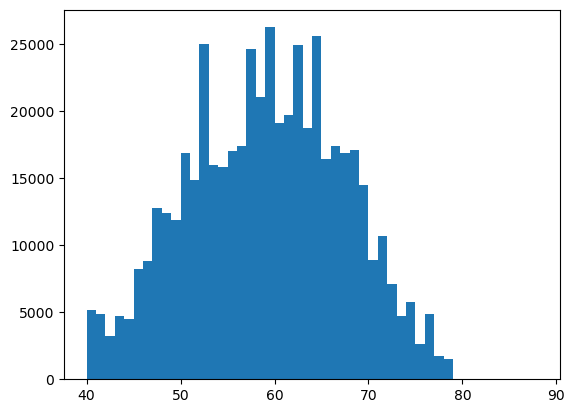

In [3]:
import shutil

trout=training_dir+'/output'
trin=training_dir+'/input'
os.makedirs(trout,exist_ok=True)
os.makedirs(trin,exist_ok=True)

for i,output_filepath in enumerate(selected_outfiles):
   
    output_filename=os.path.basename(output_filepath)
    input_filename=os.path.basename(selected_infiles[i])
    shutil.copyfile(output_filepath,os.path.join(trout,output_filename))
    shutil.copyfile(selected_infiles[i],os.path.join(trin,input_filename))


output_filepaths = sorted(glob.glob(os.path.join(trout, '*.npy')))
midi_hist(output_filepaths)
